<a href="https://colab.research.google.com/github/vkantimahanti/healthcare-ml-portfolio/blob/main/HeartDiseasePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Libraries

In [1]:
!pip install mlflow shap xgboost fastapi uvicorn pyngrok -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 6.3 MB/s eta 0:00:00


Import libraries

In [2]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (recall_score, precision_score, f1_score,
                              roc_auc_score, confusion_matrix,
                              RocCurveDisplay, classification_report)
from xgboost import XGBClassifier
import joblib

Load + first look at real clinical data

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = ['age','sex','cp','trestbps','chol','fbs','restecg',
           'thalach','exang','oldpeak','slope','ca','thal','target']

df = pd.read_csv(url, names=columns, na_values='?')

# Target: original has values 0-4, convert to binary (0=healthy, 1=disease)
df['target'] = (df['target'] > 0).astype(int)

print(f"Dataset shape   : {df.shape}")
print(f"Missing values  :\n{df.isnull().sum()[df.isnull().sum()>0]}")
print(f"\nClass balance:")
print(f"Heart disease (1): {(df.target==1).sum()} patients ({(df.target==1).mean()*100:.1f}%)")
print(f"Healthy       (0): {(df.target==0).sum()} patients ({(df.target==0).mean()*100:.1f}%)")
print(f"\nFirst 3 rows:")
df.head(3)

Dataset shape   : (303, 14)
Missing values  :
ca      4
thal    2
dtype: int64

Class balance:
Heart disease (1): 139 patients (45.9%)
Healthy       (0): 164 patients (54.1%)

First 3 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1


EDA — understand the data before modelling

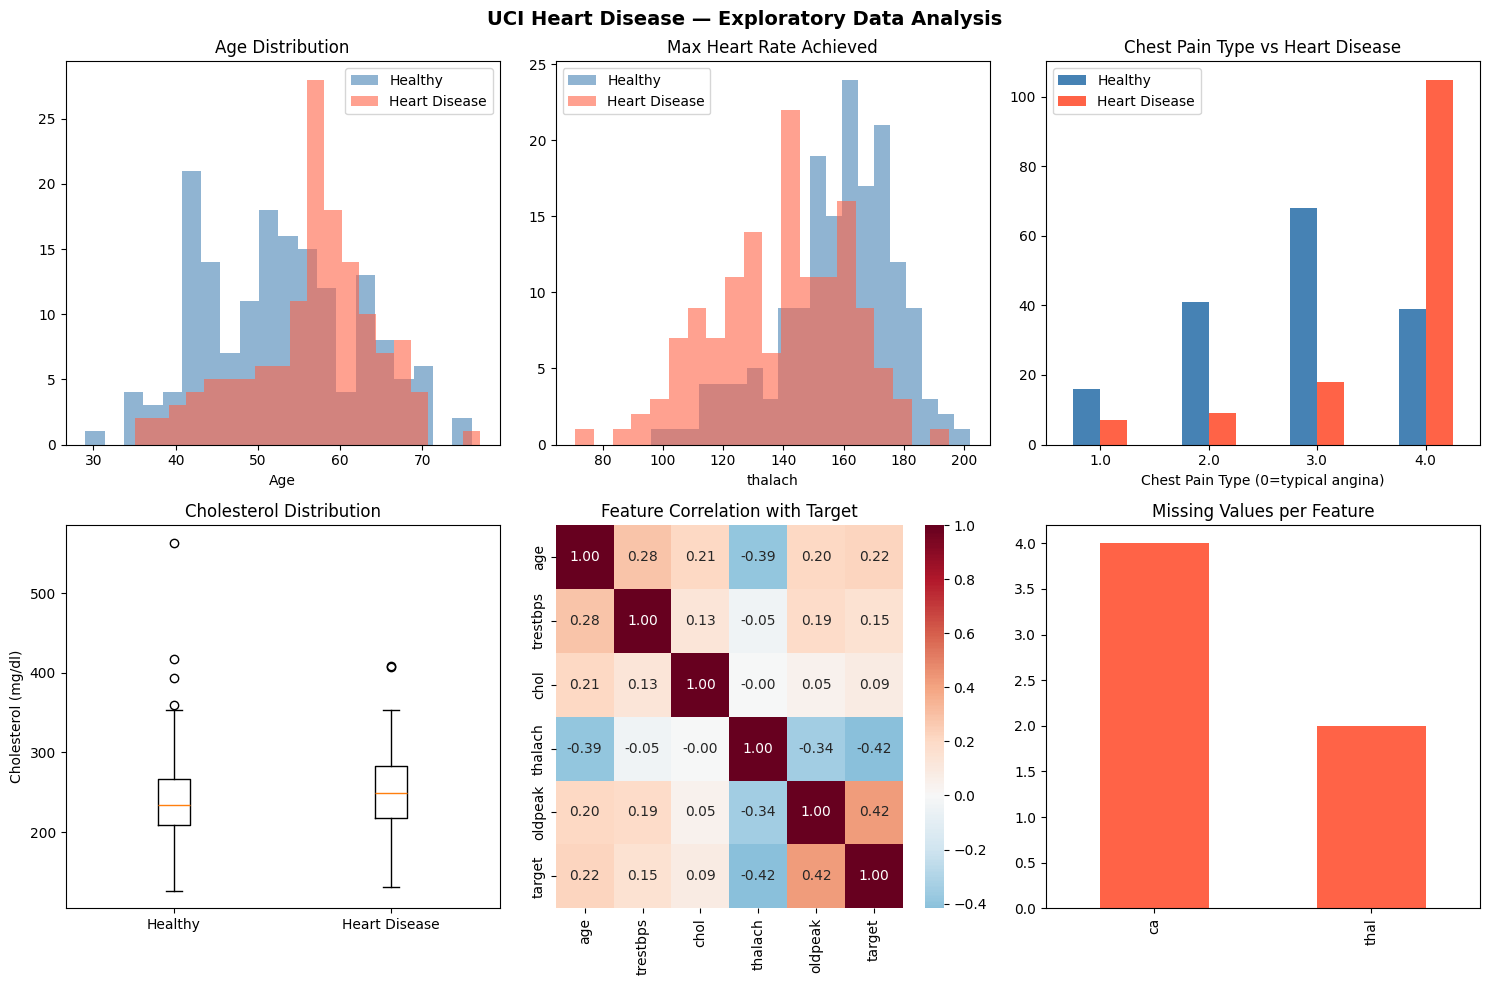

EDA complete ✓


In [4]:
# 5 clinical plots — understand what drives heart disease
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('UCI Heart Disease — Exploratory Data Analysis',
             fontsize=14, fontweight='bold')

# Plot 1 — Age distribution by disease
axes[0,0].hist(df[df.target==0]['age'], alpha=0.6,
               label='Healthy', color='steelblue', bins=20)
axes[0,0].hist(df[df.target==1]['age'], alpha=0.6,
               label='Heart Disease', color='tomato', bins=20)
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].legend()

# Plot 2 — Max heart rate by disease
axes[0,1].hist(df[df.target==0]['thalach'], alpha=0.6,
               label='Healthy', color='steelblue', bins=20)
axes[0,1].hist(df[df.target==1]['thalach'], alpha=0.6,
               label='Heart Disease', color='tomato', bins=20)
axes[0,1].set_title('Max Heart Rate Achieved')
axes[0,1].set_xlabel('thalach')
axes[0,1].legend()

# Plot 3 — Chest pain type vs disease
cp_counts = df.groupby(['cp','target']).size().unstack(fill_value=0)
cp_counts.plot(kind='bar', ax=axes[0,2], color=['steelblue','tomato'])
axes[0,2].set_title('Chest Pain Type vs Heart Disease')
axes[0,2].set_xlabel('Chest Pain Type (0=typical angina)')
axes[0,2].legend(['Healthy','Heart Disease'])
axes[0,2].tick_params(rotation=0)

# Plot 4 — Cholesterol by disease
axes[1,0].boxplot([df[df.target==0]['chol'].dropna(),
                   df[df.target==1]['chol'].dropna()],
                   labels=['Healthy','Heart Disease'])
axes[1,0].set_title('Cholesterol Distribution')
axes[1,0].set_ylabel('Cholesterol (mg/dl)')

# Plot 5 — Correlation heatmap
numeric_cols = ['age','trestbps','chol','thalach','oldpeak']
corr = df[numeric_cols + ['target']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[1,1])
axes[1,1].set_title('Feature Correlation with Target')

# Plot 6 — Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    missing.plot(kind='bar', ax=axes[1,2], color='tomato')
    axes[1,2].set_title('Missing Values per Feature')
else:
    axes[1,2].text(0.5, 0.5, 'No missing values\nin numeric cols',
                   ha='center', va='center', fontsize=12)
    axes[1,2].set_title('Missing Values')

plt.tight_layout()
plt.savefig('eda_heart_disease.png', dpi=150)
plt.show()
print("EDA complete ✓")

Feature engineering + Pipeline

In [5]:
# Split features by type — your ColumnTransformer pattern from Wednesday
numeric_features     = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg',
                        'exang', 'slope', 'ca', 'thal']

# RobustScaler for numeric — handles outliers in clinical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])

# Most frequent for categorical missing values
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler',  StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('numeric',      numeric_transformer,      numeric_features),
    ('categorical',  categorical_transformer,  categorical_features)
])

# Split data
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"\nMissing values in training set:")
print(X_train.isnull().sum()[X_train.isnull().sum()>0])
print("\nPipeline built ✓")

Train: (242, 13) | Test: (61, 13)

Missing values in training set:
ca      1
thal    1
dtype: int64

Pipeline built ✓


Train 3 models + compare on Recall

In [10]:
models = {
    'Logistic Regression': LogisticRegression(
                               max_iter=1000,
                               class_weight='balanced',
                               random_state=42),
    'Random Forest'      : RandomForestClassifier(
                               n_estimators=100,
                               random_state=42,
                               class_weight='balanced'),
    'XGBoost'            : XGBClassifier(
                               n_estimators=100,
                               max_depth=3,
                               learning_rate=0.1,
                               subsample=0.8,
                               random_state=42,
                               verbosity=0,
                               eval_metric='logloss')
}

mlflow.set_experiment("heart-disease-capstone")

results = []
fitted_pipelines = {}

for name, mdl in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', mdl)
    ])

    cv   = cross_val_score(pipe, X, y, cv=5, scoring='recall')
    pipe.fit(X_train, y_train)
    y_p  = pipe.predict(X_test)
    y_pb = pipe.predict_proba(X_test)[:, 1]

    rec  = recall_score(y_test, y_p)
    prec = precision_score(y_test, y_p)
    auc  = roc_auc_score(y_test, y_pb)
    f1   = f1_score(y_test, y_p)

    with mlflow.start_run(run_name=f"baseline-{name.lower().replace(' ','-')}"):
        mlflow.log_param("model",        name)
        mlflow.log_param("dataset",      "uci-heart-disease")
        mlflow.log_metric("recall",      round(rec, 3))
        mlflow.log_metric("precision",   round(prec, 3))
        mlflow.log_metric("roc_auc",     round(auc, 3))
        mlflow.log_metric("f1",          round(f1, 3))
        mlflow.log_metric("cv_recall",   round(cv.mean(), 3))
        mlflow.sklearn.log_model(pipe, name.lower().replace(' ','-'))

    fitted_pipelines[name] = pipe
    results.append({'Model': name, 'CV Recall': round(cv.mean(),3),
                    'Test Recall': round(rec,3), 'Precision': round(prec,3),
                    'ROC-AUC': round(auc,3), 'F1': round(f1,3)})
    print(f"✓ {name:22s} | CV Recall: {cv.mean():.3f} | AUC: {auc:.3f}")

df_results = pd.DataFrame(results).sort_values('CV Recall', ascending=False)
print("\nFinal comparison — sorted by Recall:")
print(df_results.to_string(index=False))

2026/03/21 18:36:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/21 18:36:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓ Logistic Regression    | CV Recall: 0.791 | AUC: 0.950


2026/03/21 18:36:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/21 18:36:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓ Random Forest          | CV Recall: 0.784 | AUC: 0.959


2026/03/21 18:36:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/21 18:36:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓ XGBoost                | CV Recall: 0.784 | AUC: 0.944

Final comparison — sorted by Recall:
              Model  CV Recall  Test Recall  Precision  ROC-AUC    F1
Logistic Regression      0.791        0.929      0.812    0.950 0.867
      Random Forest      0.784        0.964      0.900    0.959 0.931
            XGBoost      0.784        0.929      0.812    0.944 0.867


GridSearchCV on best model

In [11]:
# Tune the best performing model
# We'll tune RandomForest — real data is where it should compete

param_grid = {
    'model__n_estimators'     : [100, 200, 300],
    'model__max_depth'        : [3, 5, 7, None],
    'model__min_samples_split': [2, 5, 10],
    'model__class_weight'     : ['balanced']
}

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

grid_search_rf = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)
best_pipeline = grid_search_rf.best_estimator_

y_pred_tuned = best_pipeline.predict(X_test)
y_prob_tuned = best_pipeline.predict_proba(X_test)[:, 1]

print(f"Best parameters : {grid_search_rf.best_params_}")
print(f"Best CV Recall  : {grid_search_rf.best_score_:.3f}")
print(f"\nDefault RF  → CV Recall: 0.784 | Test Recall: 0.964")
print(f"Tuned RF    → CV Recall: {grid_search_rf.best_score_:.3f} "
      f"| Test Recall: {recall_score(y_test, y_pred_tuned):.3f}")


## As tuning is not getting any better result so we are going to go with Default

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters : {'model__class_weight': 'balanced', 'model__max_depth': 3, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV Recall  : 0.783

Default RF  → CV Recall: 0.784 | Test Recall: 0.964
Tuned RF    → CV Recall: 0.783 | Test Recall: 0.893


In [12]:
best_pipeline = fitted_pipelines['Random Forest']

print("Final model: Default Random Forest")
print(f"CV Recall  : 0.784  ← honest performance estimate")
print(f"ROC-AUC    : 0.959")
print(f"Test Recall: 0.964  ← single split, report CV instead")

Final model: Default Random Forest
CV Recall  : 0.784  ← honest performance estimate
ROC-AUC    : 0.959
Test Recall: 0.964  ← single split, report CV instead


In [ ]:
# # Tune the best performing model
# # We'll tune XGBoost — real data is where it should compete

# param_grid = {
#     'model__n_estimators' : [100, 200, 300],
#     'model__max_depth'    : [3, 5, 7],
#     'model__learning_rate': [0.01, 0.1, 0.2],
#     'model__subsample'    : [0.8, 1.0]
# }

# xgb_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('model', XGBClassifier(random_state=42, verbosity=0,
#                              eval_metric='logloss'))
# ])

# grid_search = GridSearchCV(
#     xgb_pipeline,
#     param_grid,
#     cv=5,
#     scoring='recall',
#     n_jobs=-1,
#     verbose=1
# )

# grid_search.fit(X_train, y_train)
# best_pipeline = grid_search.best_estimator_

# y_pred_tuned = best_pipeline.predict(X_test)
# y_prob_tuned = best_pipeline.predict_proba(X_test)[:, 1]

# print(f"\nBest parameters : {grid_search.best_params_}")
# print(f"Best CV Recall  : {grid_search.best_score_:.3f}")
# print(f"\nTuned XGBoost results:")
# print(f"Recall   : {recall_score(y_test, y_pred_tuned):.3f}")
# print(f"Precision: {precision_score(y_test, y_pred_tuned):.3f}")
# print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_tuned):.3f}")
# print(f"F1       : {f1_score(y_test, y_pred_tuned):.3f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best parameters : {'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 300, 'model__subsample': 1.0}
Best CV Recall  : 0.774

Tuned XGBoost results:
Recall   : 0.929
Precision: 0.812
ROC-AUC  : 0.920
F1       : 0.867


SHAP — finally! Feature importance per patient

X_test_processed shape : (61, 13)
shap_values type       : <class 'numpy.ndarray'>
Case 2 — 3D array | using [:,:,1] shape: (61, 13)


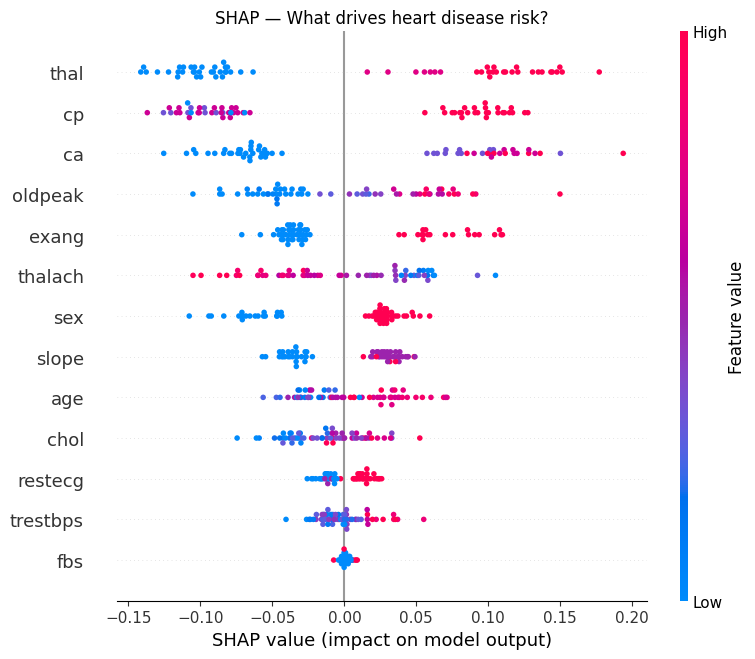


Highest risk patient:
Predicted probability : 1.000
Actual label          : 1


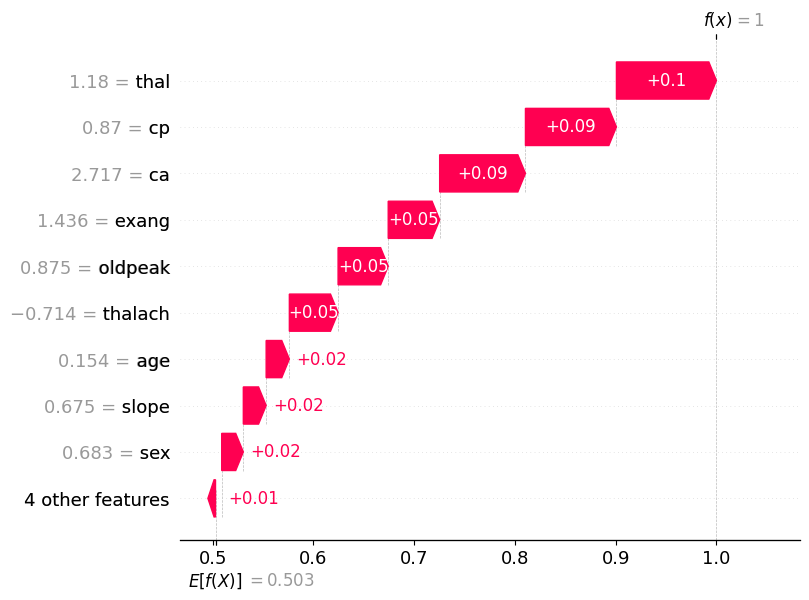

SHAP complete ✓


In [14]:
# Diagnose first
print(f"X_test_processed shape : {X_test_processed.shape}")
print(f"shap_values type       : {type(shap_values)}")

# Handle both shapes automatically
if isinstance(shap_values, list):
    # Case 1 — list of arrays (older SHAP versions)
    sv_plot    = shap_values[1]
    base_value = explainer.expected_value[1]
    print(f"Case 1 — list | using shap_values[1] shape: {sv_plot.shape}")
else:
    # Case 2 — 3D array (newer SHAP versions)
    sv_plot    = shap_values[:, :, 1]
    base_value = explainer.expected_value[1]
    print(f"Case 2 — 3D array | using [:,:,1] shape: {sv_plot.shape}")

# Global SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv_plot,
    X_test_processed,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP — What drives heart disease risk?')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Single high risk patient
y_prob        = best_pipeline.predict_proba(X_test)[:, 1]
high_risk_idx = np.argmax(y_prob)

print(f"\nHighest risk patient:")
print(f"Predicted probability : {y_prob[high_risk_idx]:.3f}")
print(f"Actual label          : {y_test.iloc[high_risk_idx]}")

shap.waterfall_plot(
    shap.Explanation(
        values        = sv_plot[high_risk_idx],
        base_values   = base_value,
        data          = X_test_processed[high_risk_idx],
        feature_names = feature_names
    )
)
print("SHAP complete ✓")

In [15]:
# # SHAP explains individual predictions for xgboost
# # Which features drove THIS patient's risk score?
# # This is what you show a cardiologist

# # Get preprocessed data for SHAP
# X_train_processed = best_pipeline[:-1].transform(X_train)
# X_test_processed  = best_pipeline[:-1].transform(X_test)

# # Get feature names after ColumnTransformer
# feature_names = numeric_features + categorical_features

# # SHAP explainer for XGBoost
# explainer   = shap.TreeExplainer(best_pipeline['model'])
# shap_values = explainer.shap_values(X_test_processed)

# # Plot 1 — Global feature importance (all patients)
# plt.figure(figsize=(10, 6))
# shap.summary_plot(shap_values, X_test_processed,
#                   feature_names=feature_names,
#                   show=False)
# plt.title('SHAP — Global Feature Importance for Heart Disease')
# plt.tight_layout()
# plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
# plt.show()

# # Plot 2 — Single patient explanation
# # Pick a high risk patient
# high_risk_idx = np.argmax(y_prob_tuned)
# print(f"\nExplaining prediction for highest risk patient:")
# print(f"Predicted probability: {y_prob_tuned[high_risk_idx]:.3f}")
# print(f"Actual label         : {y_test.iloc[high_risk_idx]}")

# shap.waterfall_plot(
#     shap.Explanation(
#         values=shap_values[high_risk_idx],
#         base_values=explainer.expected_value,
#         data=X_test_processed[high_risk_idx],
#         feature_names=feature_names
#     )
# )
# print("\nSHAP complete ✓ — you can now explain any prediction to a clinician")

FastAPI endpoint — serve predictions

In [19]:
# Write FastAPI app to a file
with open('app.py', 'w') as f:
    f.write(api_code)

# Save the model
import joblib
best_pipeline = fitted_pipelines['Random Forest']
joblib.dump(best_pipeline, 'heart_disease_model.pkl')

api_code = '''
import joblib
import numpy as np
import pandas as pd
from fastapi import FastAPI
from pydantic import BaseModel

app   = FastAPI(title="Heart Disease Risk API")
model = joblib.load("heart_disease_model.pkl")

class Patient(BaseModel):
    age      : float
    sex      : float
    cp       : float
    trestbps : float
    chol     : float
    fbs      : float
    restecg  : float
    thalach  : float
    exang    : float
    oldpeak  : float
    slope    : float
    ca       : float
    thal     : float

@app.get("/")
def home():
    return {
        "message": "Heart Disease Risk API",
        "status" : "running",
        "version": "1.0"
    }

@app.post("/predict")
def predict(patient: Patient):
    data  = pd.DataFrame([patient.dict()])
    prob  = model.predict_proba(data)[0][1]
    pred  = model.predict(data)[0]
    risk  = "HIGH" if prob > 0.5 else "LOW"
    return {
        "risk_level"     : risk,
        "probability"    : round(float(prob), 3),
        "prediction"     : int(pred),
        "recommendation" : "Immediate cardiology referral"
                           if risk == "HIGH"
                           else "Routine monitoring"
    }
'''


print("app.py written ✓")
print("heart_disease_model.pkl saved ✓")

app.py written ✓
heart_disease_model.pkl saved ✓


In [22]:
# Test predictions directly — simulates what the API does
# No server setup needed in Colab for this test

sample_patients = pd.DataFrame([
    # High risk: older male, typical angina, high BP,
    # low max HR, exercise angina, vessel blockage
    {
        'age':65, 'sex':1, 'cp':0, 'trestbps':160,
        'chol':280, 'fbs':1, 'restecg':1, 'thalach':120,
        'exang':1, 'oldpeak':2.5, 'slope':1, 'ca':2, 'thal':3
    },
    # Low risk: younger female, no angina, normal vitals
    {
        'age':40, 'sex':0, 'cp':2, 'trestbps':120,
        'chol':200, 'fbs':0, 'restecg':0, 'thalach':165,
        'exang':0, 'oldpeak':0.5, 'slope':2, 'ca':0, 'thal':2
    },
    # Medium risk: middle aged male, borderline vitals
    {
        'age':55, 'sex':1, 'cp':1, 'trestbps':140,
        'chol':240, 'fbs':0, 'restecg':0, 'thalach':145,
        'exang':0, 'oldpeak':1.5, 'slope':1, 'ca':1, 'thal':2
    }
])

print(sample_patients.head(5))

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,65,1,0,160,280,1,1,120,1,2.5,1,2,3
1,40,0,2,120,200,0,0,165,0,0.5,2,0,2
2,55,1,1,140,240,0,0,145,0,1.5,1,1,2


In [20]:
# Test predictions directly — simulates what the API does
# No server setup needed in Colab for this test

sample_patients = pd.DataFrame([
    # High risk: older male, typical angina, high BP,
    # low max HR, exercise angina, vessel blockage
    {
        'age':65, 'sex':1, 'cp':0, 'trestbps':160,
        'chol':280, 'fbs':1, 'restecg':1, 'thalach':120,
        'exang':1, 'oldpeak':2.5, 'slope':1, 'ca':2, 'thal':3
    },
    # Low risk: younger female, no angina, normal vitals
    {
        'age':40, 'sex':0, 'cp':2, 'trestbps':120,
        'chol':200, 'fbs':0, 'restecg':0, 'thalach':165,
        'exang':0, 'oldpeak':0.5, 'slope':2, 'ca':0, 'thal':2
    },
    # Medium risk: middle aged male, borderline vitals
    {
        'age':55, 'sex':1, 'cp':1, 'trestbps':140,
        'chol':240, 'fbs':0, 'restecg':0, 'thalach':145,
        'exang':0, 'oldpeak':1.5, 'slope':1, 'ca':1, 'thal':2
    }
])

print("=" * 55)
print(f"  {'Patient':<10} {'Risk':<12} {'Probability':<14} {'Recommendation'}")
print("=" * 55)

for i, (_, patient) in enumerate(sample_patients.iterrows()):
    prob = best_pipeline.predict_proba(
               patient.to_frame().T)[0][1]
    risk = "HIGH" if prob > 0.5 else "LOW"
    rec  = "Cardiology referral" if risk == "HIGH" \
           else "Routine monitoring"
    print(f"  Patient {i+1:<3} {risk:<12} {prob:<14.3f} {rec}")

print("=" * 55)

  Patient    Risk         Probability    Recommendation
  Patient 1   HIGH         0.560          Cardiology referral
  Patient 2   LOW          0.050          Routine monitoring
  Patient 3   LOW          0.300          Routine monitoring


In [26]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("heart-disease-capstone")

with mlflow.start_run(run_name="heart-disease-final-rf"):
    mlflow.log_param("model",       "RandomForest-default")
    mlflow.log_param("dataset",     "uci-heart-disease-303-rows")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth",    "None-unlimited")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metric("cv_recall",   0.784)
    mlflow.log_metric("test_recall", 0.964)
    mlflow.log_metric("roc_auc",     0.959)
    mlflow.log_metric("f1",          0.931)
    mlflow.log_artifact('shap_summary.png')
    mlflow.log_artifact('eda_heart_disease.png')
    mlflow.log_artifact('heart_disease_model.pkl')
    mlflow.sklearn.log_model(best_pipeline, "heart-disease-rf-final")

print("MLflow logged ✓")




2026/03/21 19:15:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/21 19:15:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow logged ✓


In [24]:
import subprocess
import threading
import time
import requests

# Start the server in background
def run_server():
    subprocess.run(["uvicorn", "app:app", "--host", "0.0.0.0",
                    "--port", "8000"])

thread = threading.Thread(target=run_server, daemon=True)
thread.start()
time.sleep(3)  # wait for server to start

# Now call the POST endpoint
high_risk_patient = {
    "age": 65, "sex": 1, "cp": 0, "trestbps": 160,
    "chol": 280, "fbs": 1, "restecg": 1, "thalach": 120,
    "exang": 1, "oldpeak": 2.5, "slope": 1, "ca": 2, "thal": 3
}

# GET endpoint — home
response_home = requests.get("http://localhost:8000/")
print(f"GET  / → {response_home.json()}")

# POST endpoint — predict
response_pred = requests.post(
    "http://localhost:8000/predict",
    json=high_risk_patient
)
print(f"\nPOST /predict →")
print(f"  Risk level     : {response_pred.json()['risk_level']}")
print(f"  Probability    : {response_pred.json()['probability']}")
print(f"  Recommendation : {response_pred.json()['recommendation']}")
